In [ ]:
# Import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Import NLP and Machine Learning libraries
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Download the VADER lexicon (only needs to be run once)
nltk.download('vader_lexicon', quiet=True)

# Loading the dataset
df = pd.read_csv('/content/sample_data/financial_news_events.csv')

# View the first 5 rows to ensure it loaded correctly
print("Dataset Head:")
display(df.head())

# Shape
print("Dataset Shape:")
print(df.shape)

# Summary of the dataset
df.info()

Dataset Head:


,Date,Headline,Source,Market_Event,Market_Index,Index_Change_Percent,Trading_Volume,Sentiment,Sector,Impact_Level,Related_Company,News_Url
0,2025-05-21,Nikkei 225 index benefits from a weaker yen,Times of India,Commodity Price Shock,DAX,3.52,166.45,NaN,Technology,High,Goldman Sachs,https://timesofindia.indiatimes.com/business/m...
1,2025-05-18,Government subsidy program gives a lift to the...,Financial Times,Central Bank Meeting,Shanghai Composite,-3.39,57.61,NaN,Retail,Low,ExxonMobil,https://timesofindia.indiatimes.com/business/m...
2,2025-06-25,New housing data release shows a slowdown in m...,The Hindu Business Line,Consumer Confidence Report,Shanghai Composite,-0.05,403.22,Neutral,Retail,Medium,Boeing,https://www.moneycontrol.com/us-markets/sp-500
3,2025-07-21,Massive stock buyback program announced by a c...,The Economist,Commodity Price Shock,NSE Nifty,-2.29,100.11,Positive,Consumer Goods,Low,Samsung Electronics,https://www.cnbc.com/2025/09/automotive-indust...
4,2025-07-23,Government spending bill is expected to stimul...,The Motley Fool,Inflation Data Release,Nasdaq Composite,-3.97,438.22,Negative,Consumer Goods,Low,JP Morgan Chase,https://www.bloomberg.com/australia/asx-200-pe...


Dataset Shape:
(3024, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3024 entries, 0 to 3023
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Date                  3024 non-null   object 
 1   Headline              2876 non-null   object 
 2   Source                3024 non-null   object 
 3   Market_Event          3024 non-null   object 
 4   Market_Index          3024 non-null   object 
 5   Index_Change_Percent  2863 non-null   float64
 6   Trading_Volume        3024 non-null   float64
 7   Sentiment             2853 non-null   object 
 8   Sector                3024 non-null   object 
 9   Impact_Level          3024 non-null   object 
 10  Related_Company       3024 non-null   object 
 11  News_Url              2871 non-null   object 
dtypes: float64(2), object(10)
memory usage: 283.6+ KB


In [ ]:
# Check for missing values in the DataFrame
df.isnull().sum()


,0
Date,0
Headline,148
Source,0
Market_Event,0
Market_Index,0
Index_Change_Percent,161
Trading_Volume,0
Sentiment,171
Sector,0
Impact_Level,0


In [ ]:
# 1. Clean Data: Drop rows where the Headline or Index Change is missing
df.dropna(subset=['Headline', 'Index_Change_Percent'], inplace=True)

# 2. Initialize VADER Sentiment Analyzer
sid = SentimentIntensityAnalyzer()

# 3. Create a function to get the compound score (-1.0 to +1.0)
def get_sentiment(text):
    scores = sid.polarity_scores(str(text))
    return scores['compound']

# 4. Apply the function to the Headline column to create our new feature
df['Sentiment_Score'] = df['Headline'].apply(get_sentiment)

# 5. Create Target Variable: 1 for Market Up, 0 for Market Down
df['Market_Direction'] = (df['Index_Change_Percent'] > 0).astype(int)

display(df[['Headline', 'Sentiment_Score', 'Index_Change_Percent', 'Market_Direction']].head())

,Headline,Sentiment_Score,Index_Change_Percent,Market_Direction
0,Nikkei 225 index benefits from a weaker yen,-0.0772,3.52,1
1,Government subsidy program gives a lift to the...,0.0000,-3.39,0
2,New housing data release shows a slowdown in m...,0.0000,-0.05,0
3,Massive stock buyback program announced by a c...,0.0000,-2.29,0
4,Government spending bill is expected to stimul...,0.2263,-3.97,0


In [ ]:
# Encode categorical variables (One-Hot Encoding)
cat_cols = ['Source', 'Market_Event', 'Market_Index', 'Sector', 'Impact_Level', 'Related_Company']
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Define our Feature (X) and Target (y)
X = df[['Sentiment_Score']]
y = df['Market_Direction']

# Split data: 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the Random Forest Classifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred = rf_model.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f"\nModel Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Accuracy: 51.84%

Classification Report:
              precision    recall  f1-score   support

           0       0.52      0.77      0.62       280
           1       0.51      0.25      0.34       264

    accuracy                           0.52       544
   macro avg       0.51      0.51      0.48       544
weighted avg       0.51      0.52      0.48       544



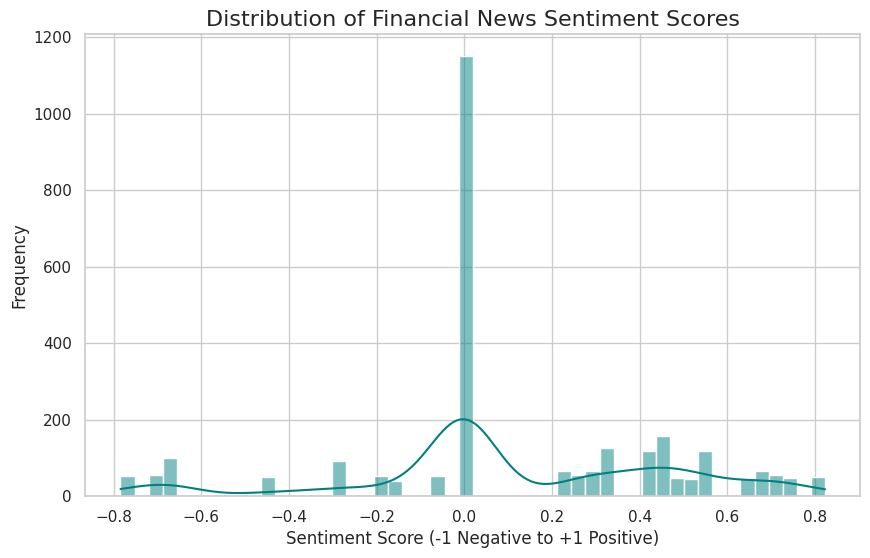

In [ ]:
# Set visualization style (histo)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 6))
sns.histplot(df['Sentiment_Score'], bins=50, kde=True, color='teal')
plt.title('Distribution of Financial News Sentiment Scores', fontsize=16)
plt.xlabel('Sentiment Score (-1 Negative to +1 Positive)', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.show()

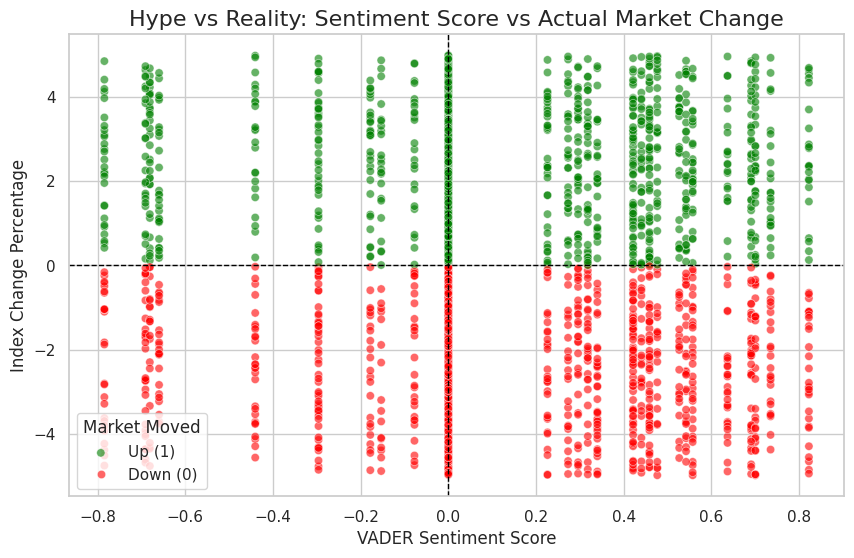

In [ ]:
#scatterplot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    x='Sentiment_Score',
    y='Index_Change_Percent',
    hue='Market_Direction',
    palette={1: 'green', 0: 'red'},
    data=df,
    alpha=0.6
)
plt.title('Hype vs Reality: Sentiment Score vs Actual Market Change', fontsize=16)
plt.xlabel('VADER Sentiment Score', fontsize=12)
plt.ylabel('Index Change Percentage', fontsize=12)
plt.axvline(0, color='black', linestyle='--', linewidth=1) # Center line for sentiment
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Center line for market return
plt.legend(title='Market Moved', labels=['Up (1)', 'Down (0)'])
plt.show()

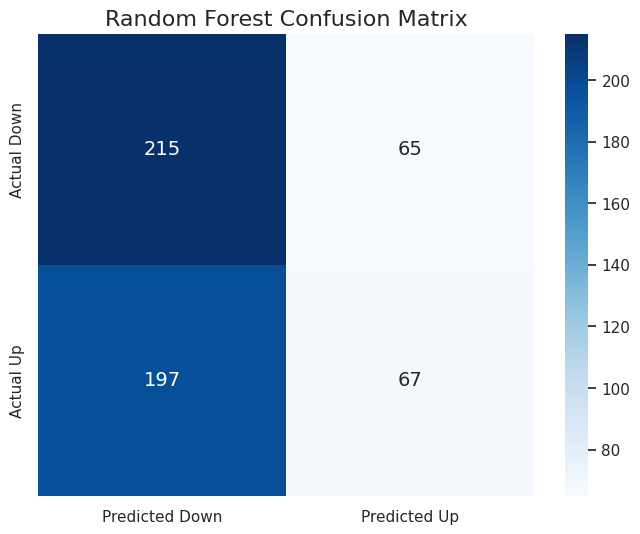

In [ ]:
#heatmap
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Down', 'Predicted Up'],
            yticklabels=['Actual Down', 'Actual Up'],
            annot_kws={"size": 14})
plt.title('Random Forest Confusion Matrix', fontsize=16)
plt.show()

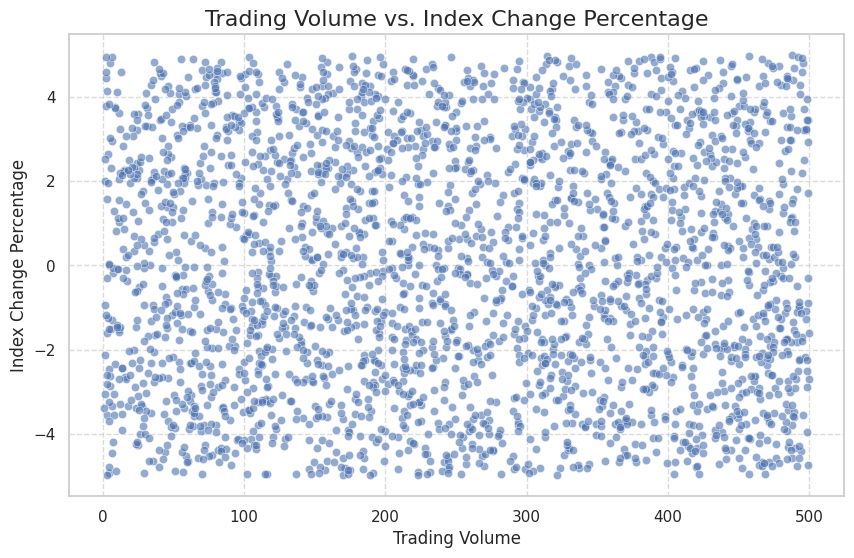

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Trading_Volume', y='Index_Change_Percent', data=df, alpha=0.6)
plt.title('Trading Volume vs. Index Change Percentage', fontsize=16)
plt.xlabel('Trading Volume', fontsize=12)
plt.ylabel('Index Change Percentage', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

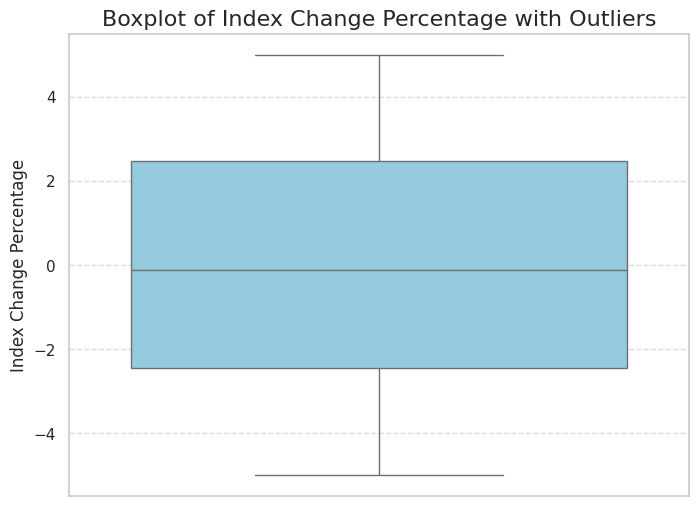

In [ ]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Index_Change_Percent'], color='skyblue')
plt.title('Boxplot of Index Change Percentage with Outliers', fontsize=16)
plt.ylabel('Index Change Percentage', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Check for missing values in the DataFrame
missing_values = df.isnull().sum()
print("Missing values per column:")
display(missing_values[missing_values > 0].sort_values(ascending=False))

Missing values per column:


,0
Sentiment,150
News_Url,135


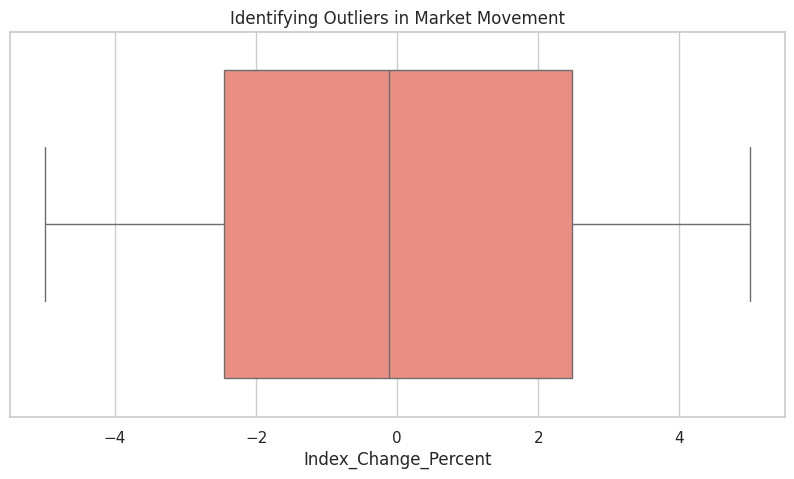

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['Index_Change_Percent'], color='salmon')
plt.title('Identifying Outliers in Market Movement')
plt.show()